# Data Dive: Predicting College Graduation Rate

#### Project Purpose:
To build and compare multiple machine learning models.

#### Business Case:
To determine which predictors have the most impact on graduation rates. Graduation rate is important for institutional reputation, revenue, and securing funding, so knowing what influences graduation rate will allow institutions to make high-impact decisions.

#### Goal: 
To accurately predict graduation rates and determine the most accurate model overall.

#### Data Dictionary:
| Field | Description |
| :-------- | :-------- |
| Private | A factor with levels No and Yes indicating private or public university |
| Apps | Number of applications received |
| Accept | Number of applications accepted |
| Enroll | Number of new students enrolled |
| Top10perc Pct. | New students from top 10% of H.S. class |
| Top25perc: Pct. | New students from top 25% of H.S. class |
| F.Undergrad | Number of full-time undergraduates |
| P.Undergrad | Number of part-time undergraduates |
| Outstate | Out-of-state tuition |
| Room.Board | Room and board costs |
| Books | Estimated book costs |
| Personal | Estimated personal spending |
| PhD | Pct. of faculty with Ph.D.’s |
| Terminal | Pct. of faculty with terminal degree |
| S.F.Ratio | Student/faculty ratio |
| perc.alumni | Pct. alumni who donate |
| Expend | Instructional expenditure per student |
| Grad.Rate | Graduation rate |

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
from  matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

%matplotlib inline
sns.set_style('whitegrid')

pd.set_option('display.max_columns',500) # up to 500 columns can be displayed when viewing a dataframe

import warnings
warnings.filterwarnings("ignore")

### Import data, analyze descriptive statistics

In [2]:
data = pd.read_csv("college_data.csv")
data.head() # view first 5 rows

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), object(1)
memory usage: 

In [4]:
data.describe() # descriptive statistics

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### Data cleaning

In [5]:
# map 'Private' to a numeric variable
data["Private"] = data["Private"].map({"Yes": 1, "No": 0})

# check data types to confirm changes
data.dtypes 

Private          int64
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD              int64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [6]:
print("Duplicate values:", data.duplicated().sum()) # check for duplicate values

Duplicate values: 0


In [7]:
data.isnull().sum() # check for null values

Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [8]:
data[data["Grad.Rate"] > 100] # check for graduation rate over 100%

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
95,1,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118


In [9]:
data["Grad.Rate"] = data["Grad.Rate"].clip(upper=100) # cap graduation rate at 100%

### Exploratory data analysis (EDA)

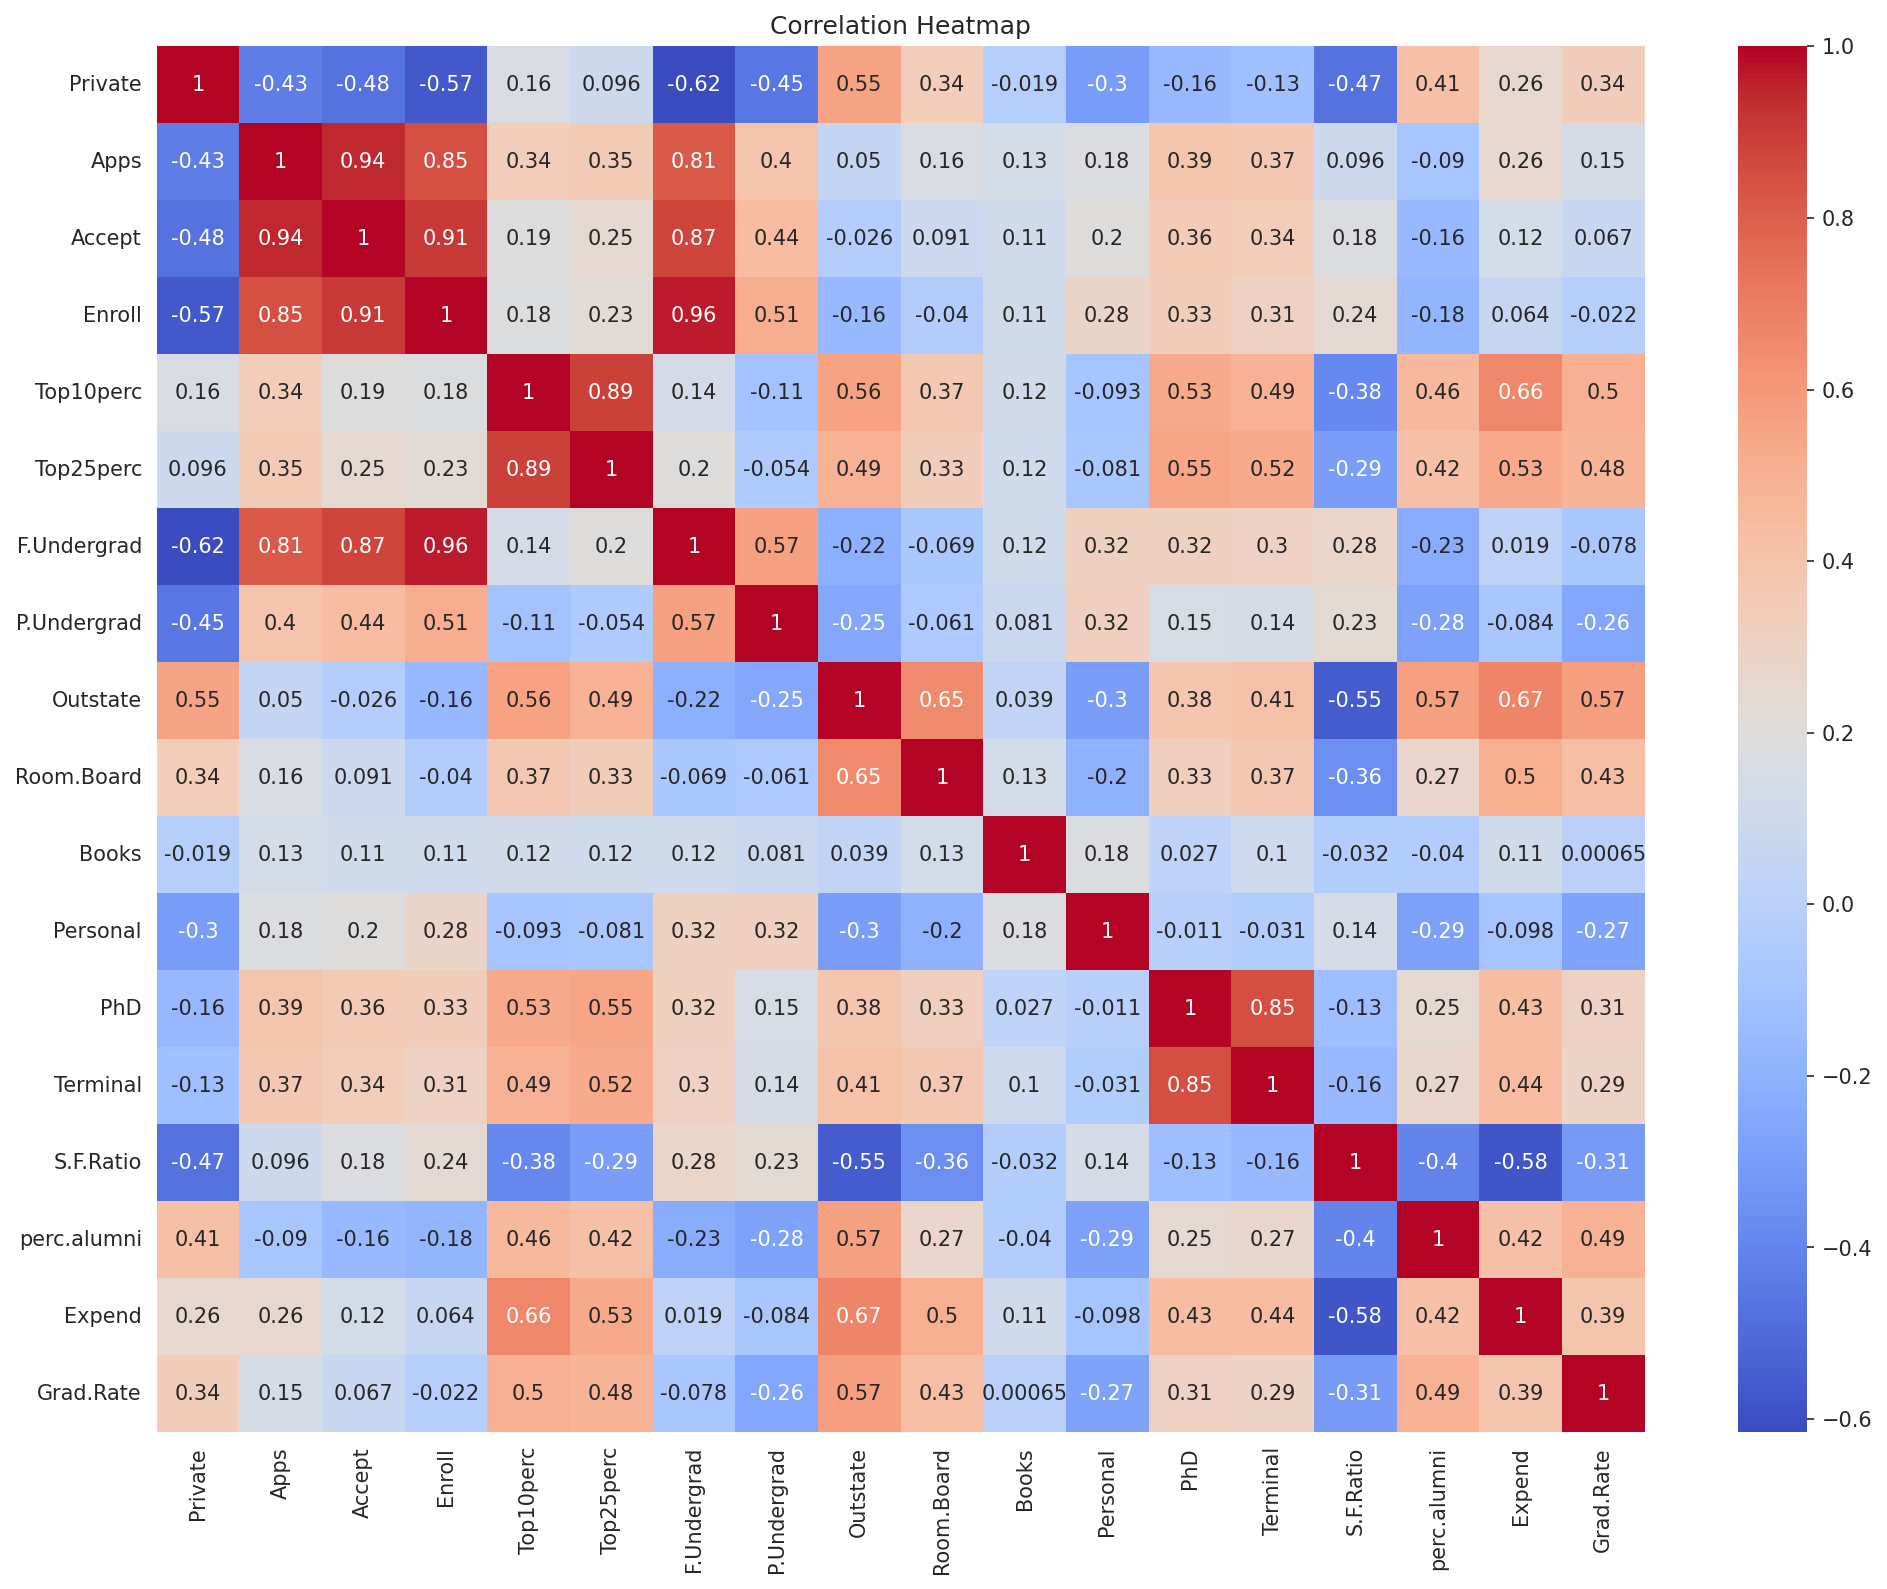

In [10]:
# correlation heatmap
plt.figure(figsize=(16, 12), dpi=150)
sns.heatmap(data.corr(), 
            cmap="coolwarm", 
            annot=True)
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='Grad.Rate', ylabel='Count'>

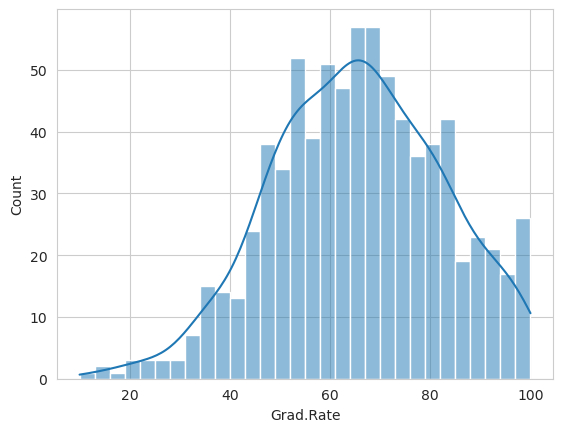

In [11]:
sns.histplot(data["Grad.Rate"], bins=30, kde=True) # graduation rate distribution

In [12]:
corrs = data.corr(numeric_only=True)["Grad.Rate"].sort_values(ascending=False)
print(corrs)

Grad.Rate      1.000000
Outstate       0.573612
Top10perc      0.498118
perc.alumni    0.492887
Top25perc      0.480346
Room.Board     0.425808
Expend         0.392195
Private        0.336490
PhD            0.310292
Terminal       0.293533
Apps           0.146964
Accept         0.066762
Books          0.000649
Enroll        -0.022049
F.Undergrad   -0.078293
P.Undergrad   -0.257135
Personal      -0.268588
S.F.Ratio     -0.307838
Name: Grad.Rate, dtype: float64


#### Regression plots
Regression plots for features with highest correlation with graduation rate.

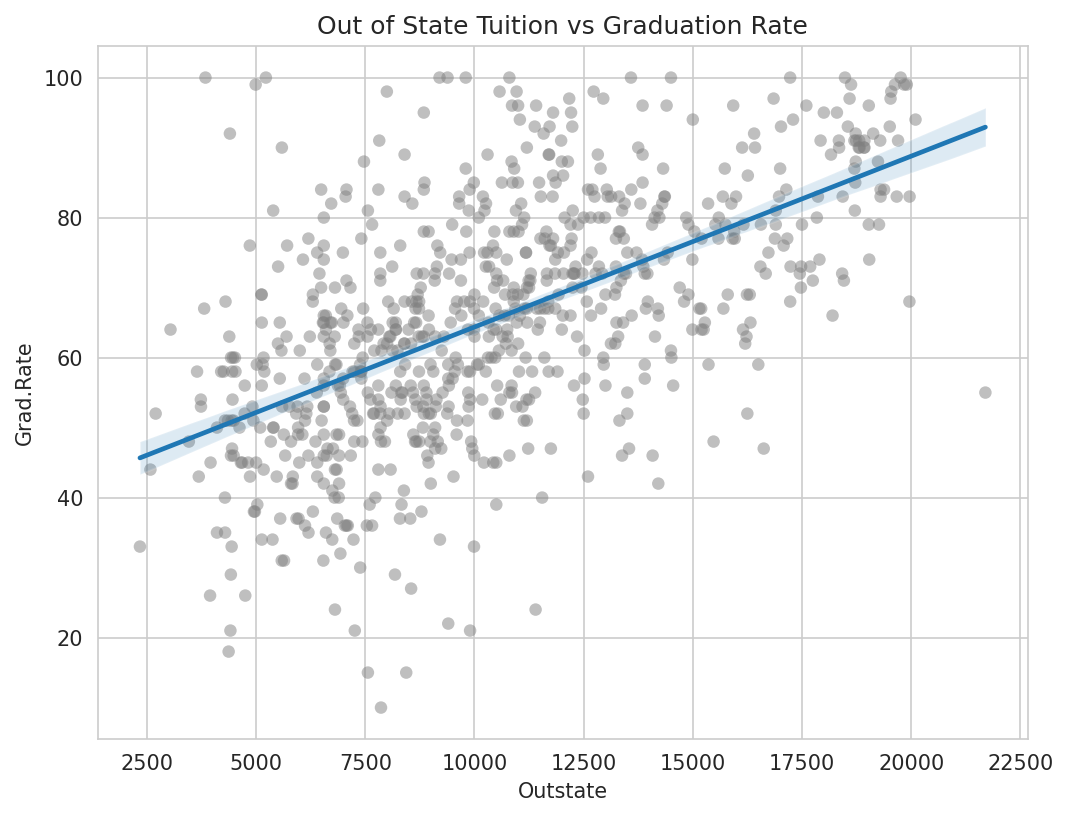

In [13]:
plt.figure(figsize=(8,6), dpi=150)
sns.regplot(x="Outstate", y="Grad.Rate", data=data, 
            scatter_kws={"color": "gray", "edgecolor": "none", "alpha": 0.5})
plt.title("Out of State Tuition vs Graduation Rate")
plt.show()

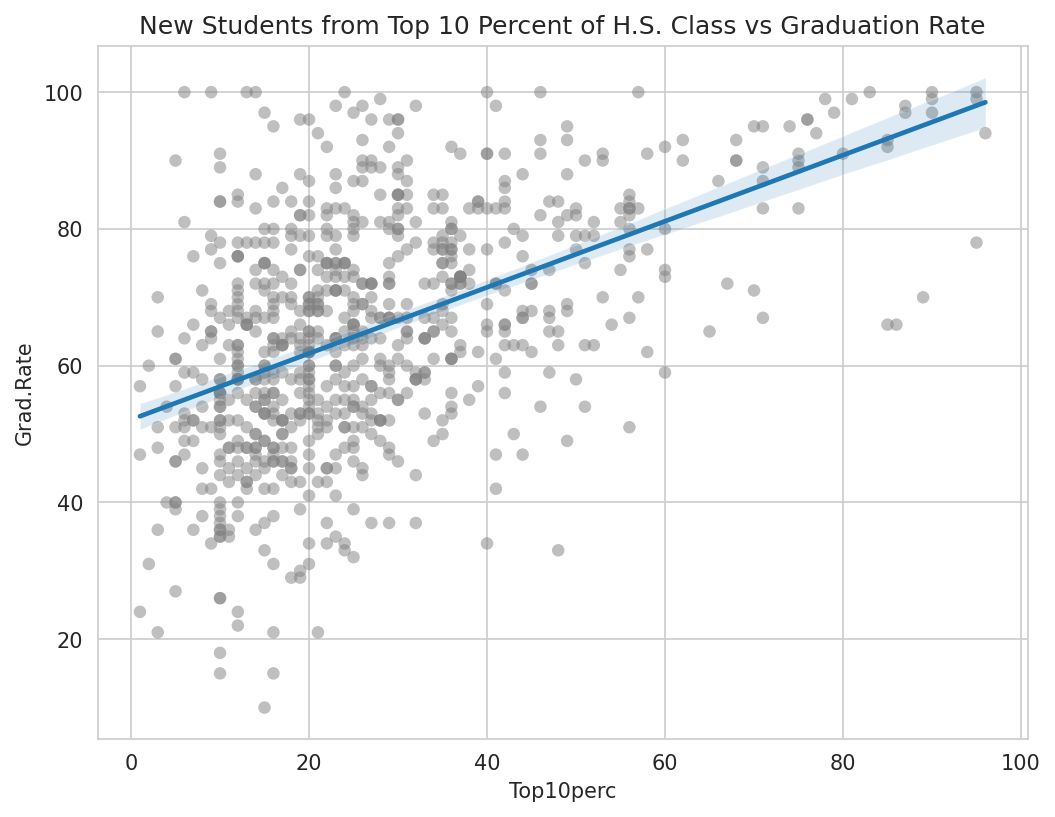

In [14]:
plt.figure(figsize=(8,6), dpi=150)
sns.regplot(x="Top10perc", y="Grad.Rate", data=data, 
            scatter_kws={"color": "gray", "edgecolor": "none", "alpha": 0.5})
plt.title("New Students from Top 10 Percent of H.S. Class vs Graduation Rate")
plt.show()

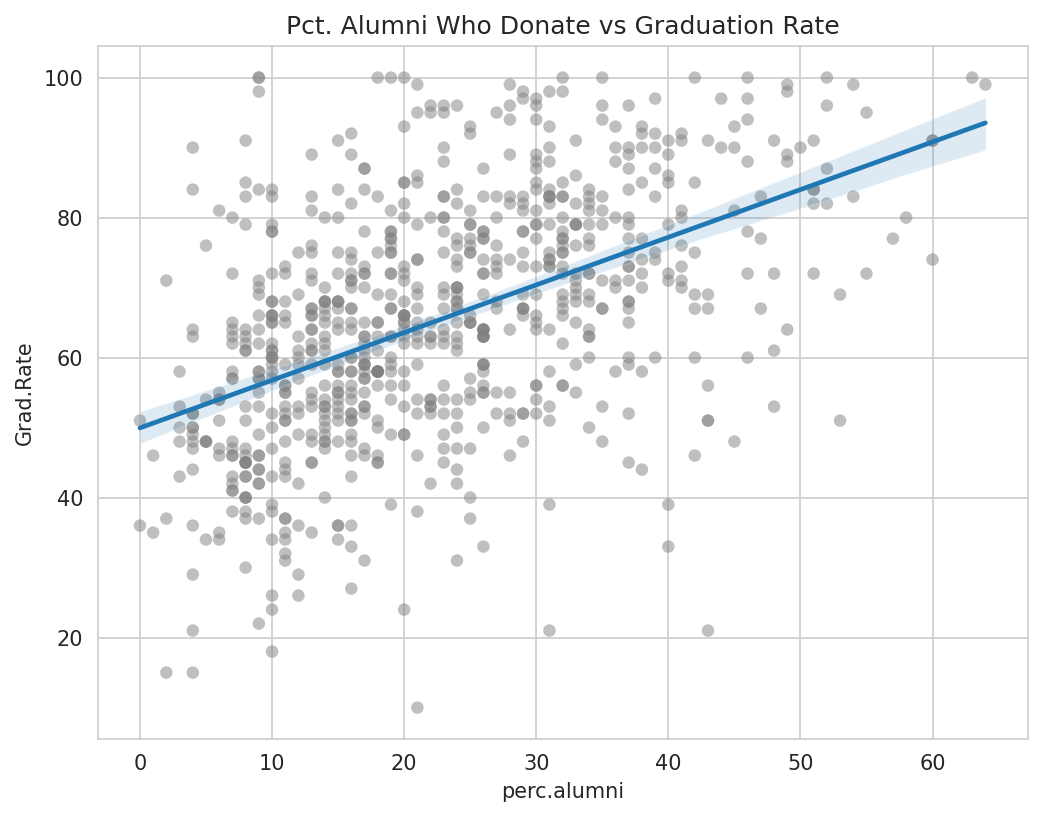

In [15]:
plt.figure(figsize=(8,6), dpi=150)
sns.regplot(x="perc.alumni", y="Grad.Rate", data=data, 
            scatter_kws={"color": "gray", "edgecolor": "none", "alpha": 0.5})
plt.title("Pct. Alumni Who Donate vs Graduation Rate")
plt.show()

### Prepare for regression modeling

In [16]:
# separate features and target
X = data.drop("Grad.Rate", axis=1)
y = data["Grad.Rate"]

In [17]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Why are we scaling the data?
- Since variables like `Apps` and `Books` are on very different scales, scaling helps to put them (and all other independent features) on the same numerical scale. Overall, scaling helps prevent feature dominance and optimize model performance.

In [19]:
# function to evaluate model
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("-" * 30)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 3))
    print()

### Simple linear regression model

In [20]:
# baseline simple linear regression model
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# make predictions
y_linear_pred = linear_model.predict(X_test_scaled)

In [22]:
evaluate_model(y_test, y_linear_pred, "Simple Linear Regression")

Simple Linear Regression
------------------------------
MAE: 8.18
RMSE: 10.78
R²: 0.506



In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

        Feature  Coefficient
1          Apps     5.942827
8      Outstate     3.948706
15  perc.alumni     3.597819
5     Top25perc     2.958875
12          PhD     2.169639
9    Room.Board     1.938781
3        Enroll     1.822791
0       Private     1.503840
4     Top10perc     0.517579
14    S.F.Ratio     0.011581
10        Books    -0.517906
11     Personal    -1.058773
13     Terminal    -1.666144
7   P.Undergrad    -2.153003
2        Accept    -2.362360
16       Expend    -2.495382
6   F.Undergrad    -2.685349


### Ridge regression

In [24]:
ridge_model = Ridge(alpha=1.0) # baseline model
ridge_model.fit(X_train_scaled, y_train) # train model
ridge_pred = ridge_model.predict(X_test_scaled) # make predictions

In [25]:
evaluate_model(y_test, ridge_pred, "Ridge Regression Baseline")

Ridge Regression Baseline
------------------------------
MAE: 8.18
RMSE: 10.78
R²: 0.506



In [26]:
# hyperparameter tuning
ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    cv=5,
    scoring="r2"
)

# train model
ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_) # print best hyperparameteres

best_ridge = ridge_grid.best_estimator_ # extract best performing model

ridge_best_pred = best_ridge.predict(X_test_scaled) # make predictions

Best Ridge Parameters:
{'alpha': 100}


In [27]:
evaluate_model(y_test, ridge_best_pred, "Ridge Regression Tuned")

Ridge Regression Tuned
------------------------------
MAE: 8.09
RMSE: 10.59
R²: 0.523



### LASSO regression

In [28]:
lasso_model = Lasso(alpha=0.1) # baseline model
lasso_model.fit(X_train_scaled, y_train) # train model
lasso_pred = lasso_model.predict(X_test_scaled) # make predictions

In [29]:
evaluate_model(y_test, lasso_pred, "LASSO Regression Baseline")

LASSO Regression Baseline
------------------------------
MAE: 8.14
RMSE: 10.69
R²: 0.514



In [30]:
# hyperparameter tuning
lasso = Lasso(max_iter=10000)

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_params,
    cv=5,
    scoring="r2"
)

# train model
lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso Parameters:")
print(lasso_grid.best_params_) # print best parameters

best_lasso = lasso_grid.best_estimator_ # extract best model

lasso_best_pred = best_lasso.predict(X_test_scaled) # make predictions

Best Lasso Parameters:
{'alpha': 0.1}


In [31]:
evaluate_model(y_test, lasso_best_pred, "LASSO Regression Tuned")

LASSO Regression Tuned
------------------------------
MAE: 8.14
RMSE: 10.69
R²: 0.514



### Random forest regressor

In [32]:
# baseline model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# train model
rf_model.fit(X_train, y_train)

# make predictions
rf_pred = rf_model.predict(X_test)

In [33]:
evaluate_model(y_test, rf_pred, "Random Forest Regressor Baseline")

Random Forest Regressor Baseline
------------------------------
MAE: 8.15
RMSE: 10.53
R²: 0.529



In [34]:
# hyperparameter tuning
rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# train model
rf_random.fit(X_train, y_train)

print("Best RF Parameters:")
print(rf_random.best_params_) # print best parameters

best_rf = rf_random.best_estimator_ # extract best model

rf_best_pred = best_rf.predict(X_test) # make predictions

Best RF Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [35]:
evaluate_model(y_test, rf_best_pred, "Random Forest Regressor Tuned")

Random Forest Regressor Tuned
------------------------------
MAE: 7.86
RMSE: 10.16
R²: 0.561



### Feature importance

In [39]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

        Feature  Importance
8      Outstate    0.183978
15  perc.alumni    0.120061
5     Top25perc    0.081850
4     Top10perc    0.081827
9    Room.Board    0.070644
16       Expend    0.062429
1          Apps    0.052545
11     Personal    0.048128
7   P.Undergrad    0.044424
6   F.Undergrad    0.043678
3        Enroll    0.040759
2        Accept    0.035359
12          PhD    0.029885
14    S.F.Ratio    0.029265
13     Terminal    0.028758
10        Books    0.026319
0       Private    0.020092


### Model conclusions
- The strongest overall model was the **fine-tuned random forest model**. Because this model had the lowest MAE/RMSE and highest R², the predictions are the closest to the real values (low errors), the least likely to make extreme errors, and the best at explaining the overall trends in the data.
    - The three strongest predictors from this model were: 